In [75]:
#imports
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import pandas as pd
import numpy as np
import time

from dask.distributed import Client, LocalCluster
from formulaic import Formula

import scMPRAforge as scm


In [76]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
cluster=LocalCluster()
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

In [83]:
shendure=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/shendure/shendure_counts_grouped.txt")

scMPRAforge: INFO: Dropping cell-types & cres with below 3 (MIN_PTS) observations: f{'cre_id': ['Col1a1_chr11_15306', 'Col1a2_chr6_65', 'minP_w_20bp_buffer'], 'cell_type': []}
scMPRAforge: INFO: Dropping 4990 cells with no MPRA UMIs, leaving 38457.


In [84]:
shendure_subset=shendure.data[shendure.data["cell_type"]=="EpiblastPrimitiveStreak"]
shendure_mean=shendure_subset.groupby("cre_id")["umis_mpra_bc"].agg("mean").sort_values()
shendure_mean

cre_id
Cited2_chr10_1239      0.000000
Txndc12_chr4_7969      0.000000
Tgfbi_chr13_5711       0.000000
Klf4_chr4_3952         0.000000
Sox17_chr1_68          0.000000
                        ...    
Tubb2b_chr13_2576      8.500901
Btg1_chr10_9578       11.981481
ubcP                  52.924898
pgk1P                153.751531
eef1aP               439.323718
Name: umis_mpra_bc, Length: 209, dtype: float64

In [ ]:
#shendure_subset["cre_id"] = shendure_subset["cre_id"].replace("noP", "minus_ctrl").replace("minP", "minus_ctrl")
#shendure_subset[(shendure_subset["cre_id"] == "noP") | (shendure_subset["cre_id"] == "minP")]#["cre_id"]="minus_ctrl"

In [85]:
shendure_subset

,cell_bc,rep_id,cre_class,cre_id,cell_type,transfection_bc,mpra_bc,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc,gex_umi,normalized_umis_mpra_bc,ln_cell_umis_mpra
9,2B1_AAACCCACACGTCGTG-1,2B1,devCRE,Bend5_chr4_8170,EpiblastPrimitiveStreak,ATGCATGTCTTAGGGG,GCATCAATACAAGAC,92,90,0,0,4527,0.000000,2.197225
10,2B1_AAACCCACACGTCGTG-1,2B1,devCRE,Bend5_chr4_8199,EpiblastPrimitiveStreak,AAAGACGCGTGTGGGA,ACTAGCCCCCAATCG,65,64,0,0,4527,0.000000,2.197225
11,2B1_AAACCCACACGTCGTG-1,2B1,devCRE,Bend5_chr4_8201,EpiblastPrimitiveStreak,"GCTTAATGGCGCAGTT, CGGCCCCGAACGCTGC","CCACCCACTGCACCG, TATAGATTGCACGTT",292,274,0,0,9054,0.000000,2.197225
12,2B1_AAACCCACACGTCGTG-1,2B1,devCRE,Btg1_chr10_9572,EpiblastPrimitiveStreak,CATTACCACTTACCAT,CTGCCCTAAATCTAT,331,317,0,0,4527,0.000000,2.197225
13,2B1_AAACCCACACGTCGTG-1,2B1,devCRE,Btg1_chr10_9588,EpiblastPrimitiveStreak,ACTTGGTAACGGGGTT,AAAACGCACCAAGGT,121,113,0,0,4527,0.000000,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736477,B2_TTTGGTTAGTGAGTTA-1,B2,devCRE,Lamc1_chr1_12185,EpiblastPrimitiveStreak,AAGGCTGCATTTCGTG,ACTCAGCTCACCGCA,215,191,0,0,1258,0.000000,2.890372
736478,B2_TTTGGTTAGTGAGTTA-1,B2,devCRE,Sparc_chr11_7230,EpiblastPrimitiveStreak,AGAAGGATCTGTATGG,AGTTTACCCTCCCCT,146,127,0,0,1258,0.000000,2.890372
736479,B2_TTTGGTTAGTGAGTTA-1,B2,promoters,minP,EpiblastPrimitiveStreak,"AACTACTCAAATGAGA, GCCTCTCCGCTGGCAT, ACCACATCAC...","CAGCGAAACTAAACG, GCGCACACCCCCCGG, CACAGCTTGGCAGTT",389,343,0,0,3774,0.000000,2.890372
736480,B2_TTTGGTTAGTGAGTTA-1,B2,promoters,noP,EpiblastPrimitiveStreak,CCGTAAGTCACTAACC,CACCCCGCACAGCGT,210,184,0,0,1258,0.000000,2.890372


In [86]:
zeroes=shendure_subset[shendure_subset['umis_mpra_bc']==0].groupby('rep_id').size()
total=shendure_subset.groupby('rep_id').size()
emperical_zero=pd.DataFrame({'zeroes':zeroes,'total':total})
emperical_zero["fraction_zero"]=emperical_zero["zeroes"]/emperical_zero["total"]
emperical_zero["fraction_nonzero"]=1-emperical_zero["fraction_zero"]
emperical_zero

,zeroes,total,fraction_zero,fraction_nonzero
rep_id,,,,
2B1,11102,13519,0.821215,0.178785
2B2,13758,16587,0.829445,0.170555
A1,7879,9626,0.818512,0.181488
A2,8022,9877,0.812190,0.187810
B1,6350,7791,0.815043,0.184957
B2,6404,7894,0.811249,0.188751


In [87]:
def create_matricies(nb_formula,zi_formula,shared_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    S=Formula(shared_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z,
        'shared_regressors':S
    }

matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cre_id)-1",
                           zi_formula="C(rep_id)",
                           shared_formula='ln_cell_umis_mpra',
                           scmpra=shendure_subset)

In [8]:
#remove
#matricies["nb_regressors"]=matricies["nb_regressors"].drop(columns='C(cre_id)[T.minP]')

In [88]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """

    from tensorzinb.tensorzinb import TensorZINB

    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"],
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except InvalidIndexError:
        return "index_error"

    return zinb_result

model=tensorzinb_fit(matricies)

In [89]:
model

{'llf_total': -82839.66334007494,
 'llfs': array([-82839.66334007]),
 'aic_total': 166111.32668014988,
 'aics': array([166111.32668015]),
 'df_model_total': 216,
 'df': 216,
 'weights': {'x_mu': array([[-3.5156834e+00],
         [-3.2037926e+00],
         [-4.0384369e+00],
         [-3.2699902e+00],
         [ 2.3768738e-01],
         [-3.3155279e+00],
         [-5.0706935e+00],
         [-3.1879978e+00],
         [-3.1264169e+00],
         [-4.3424096e+00],
         [ 2.4845910e+00],
         [-3.9903548e+00],
         [-2.7995620e+00],
         [-3.2520244e+00],
         [-3.7976377e+00],
         [-2.7822268e-01],
         [ 1.0867782e+00],
         [ 1.9339750e+00],
         [-2.6629155e+00],
         [-9.1955692e-01],
         [-3.0495102e+00],
         [-3.8053546e+00],
         [-1.9259418e+01],
         [-3.1882339e+00],
         [-4.6477909e+00],
         [-2.0864789e+00],
         [ 1.0877783e+00],
         [-3.8876750e+00],
         [-3.3451879e+00],
         [-1.4509927e+00

In [90]:
model["weights"]["x_pi"]

array([[-4.9934306 ],
       [ 0.20204712],
       [ 0.576484  ],
       [ 0.7382289 ],
       [ 0.65264726],
       [ 0.67290974]], dtype=float32)

In [91]:
matricies["zi_regressors"]

,Intercept,C(rep_id)[T.2B2],C(rep_id)[T.A1],C(rep_id)[T.A2],C(rep_id)[T.B1],C(rep_id)[T.B2]
9,1.0,0,0,0,0,0
10,1.0,0,0,0,0,0
11,1.0,0,0,0,0,0
12,1.0,0,0,0,0,0
13,1.0,0,0,0,0,0
...,...,...,...,...,...,...
736477,1.0,0,0,0,0,1
736478,1.0,0,0,0,0,1
736479,1.0,0,0,0,0,1
736480,1.0,0,0,0,0,1


In [92]:
1/(1+np.exp(-(-0.89038604+-3.7672174)))

0.009399978498313246

In [93]:
#x_mu * beta_g,mu
linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]

#x_mu * beta_g,mu + Z_mu * alpha_mu
#linear_mu=(matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]+
#        matricies["shared_regressors"].to_numpy() @ model["weights"]["z_mu"])
mu_predictions=np.exp(linear_mu)

#x_pi * beta_g,pi + Z_pi * alpha_pi
#linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"]+
#           matricies["shared_regressors"].to_numpy() @ model["weights"]["z_pi"])


#x_pi * beta_g,pi
linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

In [94]:
cre_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cre_id"]
cre_labeling=cre_labeling.str.removeprefix("T.")

In [95]:
mu_predictions_df=pd.DataFrame({'cre_id':cre_labeling,'mu':mu_predictions.squeeze()})
mu_predictions_df.sort_values(by='mu')

,cre_id,mu
386295,Foxa2_chr2_13858,1.492537e-17
329585,Foxa2_chr2_13858,1.492537e-17
354123,Foxa2_chr2_13858,1.492537e-17
691069,Foxa2_chr2_13858,1.492537e-17
83908,Foxa2_chr2_13858,1.492537e-17
...,...,...
447919,eef1aP,2.697993e+143
414482,eef1aP,2.697993e+143
458144,eef1aP,2.697993e+143
424154,eef1aP,2.697993e+143


In [96]:
mu_summary=mu_predictions_df.groupby("cre_id").agg("mean")
mu_summary = mu_summary.merge(shendure_mean.rename_axis('cre_id').reset_index(), on='cre_id', how='left')
mu_summary.sort_values(by="mu")

,cre_id,mu,umis_mpra_bc
71,Foxa2_chr2_13858,1.492537e-17,0.000000
103,Klf4_chr4_3952,1.662458e-11,0.000000
51,Col5a1_chr2_2586,1.854334e-10,0.000000
199,Txndc12_chr4_7969,4.892626e-10,0.000000
22,Cited2_chr10_1239,4.322558e-09,0.000000
...,...,...,...
190,Tubb2b_chr13_2576,8.529159e+00,8.500901
10,Btg1_chr10_9578,1.199621e+01,11.981481
208,ubcP,5.297089e+01,52.924898
207,pgk1P,2.563335e+19,153.751531


In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

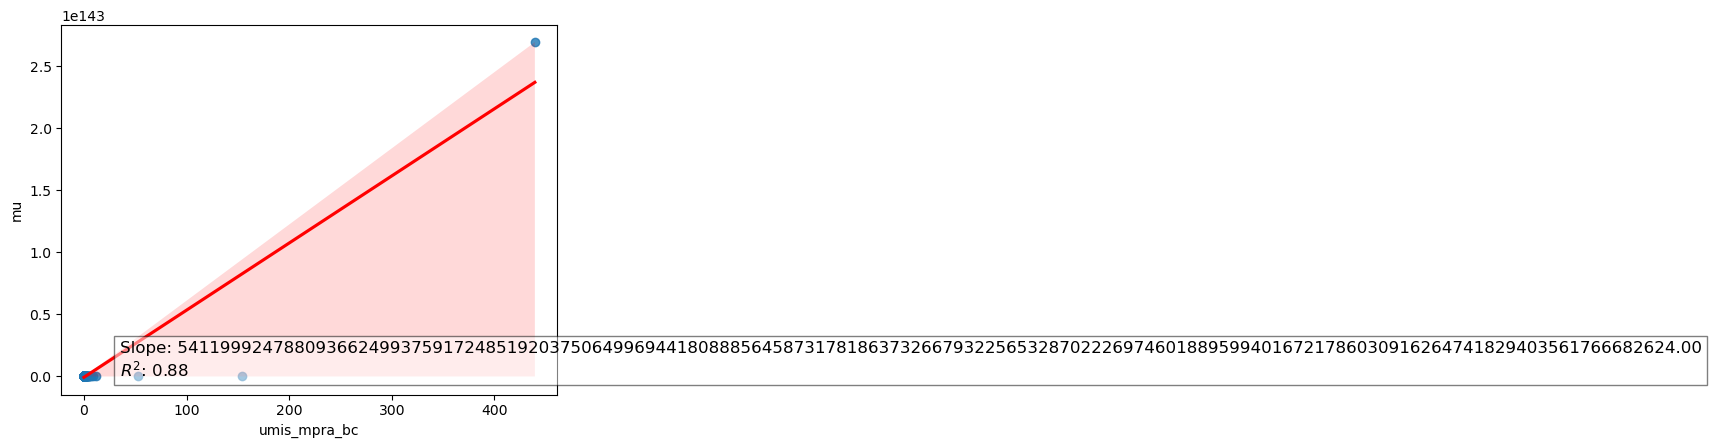

In [98]:
x = mu_summary["umis_mpra_bc"]
y = mu_summary["mu"]

# Fit regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plot
sns.regplot(x=x, y=y, scatter=True, line_kws={"color": "red"})
plt.text(
    35, 300,  # coordinates for text box
    f"Slope: {slope:.2f}\n$R^2$: {r_value**2:.2f}",
    fontsize=12, bbox=dict(facecolor='white', alpha=0.5)
)

plt.show()


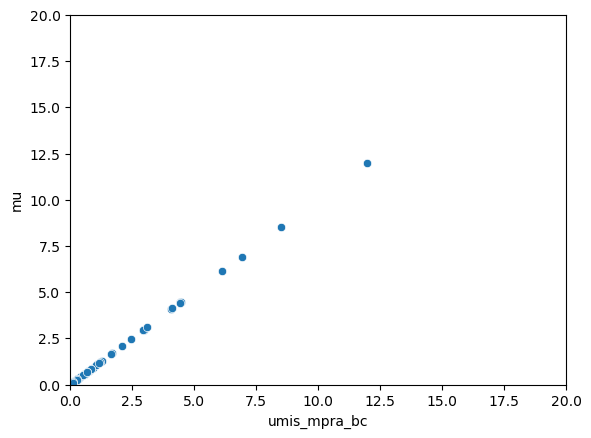

In [99]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 20)   # Set x-axis limits
plt.ylim(0, 20)   # Set y-axis limits
plt.show()

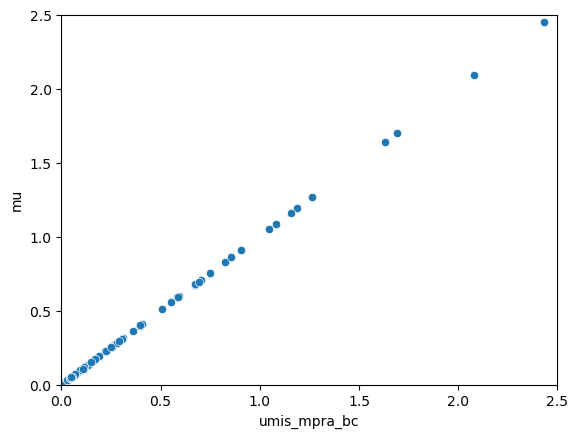

In [100]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 2.5)   # Set x-axis limits
plt.ylim(0, 2.5)   # Set y-axis limits
plt.show()

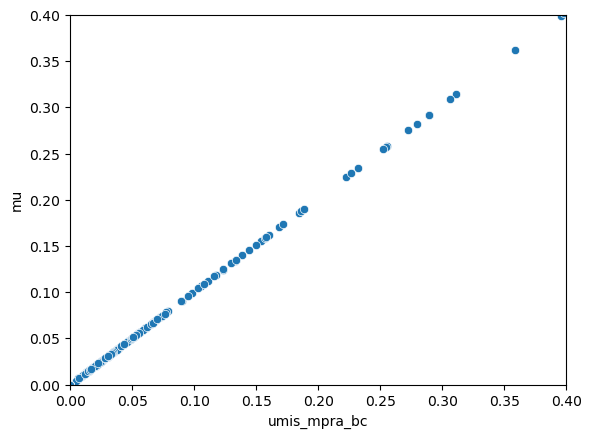

In [101]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 0.4)   # Set x-axis limits
plt.ylim(0, 0.4)   # Set y-axis limits
plt.show()

In [102]:
replicate_labeling=scm.undo_one_hot_encoding(matricies["zi_regressors"])["rep_id"]
replicate_labeling=replicate_labeling.str.removeprefix("T.")
zi_predictions_df=pd.DataFrame({'rep_id':replicate_labeling,'zi':zi_predictions.squeeze()})
zi_summary=zi_predictions_df.groupby("rep_id").agg("mean")
zi_summary



,zi
rep_id,
2B2,0.007561
A1,0.011927
A2,0.013992
B1,0.012859
B2,0.013119


------

In [70]:
#dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
#primordial=scm.ortho()
#primordial.criss_cross(client=client,dat=dat)
#primordial.extract_params(client)

In [71]:
#primordial.by_cell_type_parameters.result().theta

In [74]:
cluster.close()